# Importation des bibliothèques

In [ ]:
import pandas as pd
from utils import  beau_tableau, carte_par_candidat, cartes_plusieurs_candidats 

# Importation du dataset

In [2]:
# Importation
df = pd.read_csv(
 'https://www.data.gouv.fr/fr/datasets/r/182268fc-2103-4bcb-a850-6cf90b02a9eb' 
)
# Aperçu
print(f"Dimension du dataset : {df.shape}")
print(f"Type des variables  : {df.dtypes}")

print("Aperçu du dataset  : ")
print(df.head(2))


Dimension du dataset : (528675, 7)
Type des variables  : code_departement       object
libelle_departement    object
code_commune            int64
libelle_commune        object
prenom                 object
nom                    object
voix                    int64
dtype: object
Aperçu du dataset  : 
  code_departement libelle_departement  code_commune          libelle_commune  \
0               01                 Ain             1  L'Abergement-Clémenciat   
1               01                 Ain             2    L'Abergement-de-Varey   

     prenom      nom  voix  
0  Nathalie  ARTHAUD     3  
1  Nathalie  ARTHAUD     2  


/tmp/ipykernel_11386/3014764861.py:2: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


On va spécifier les types des variables pour un travail plus fluide.

In [3]:
df = df.convert_dtypes()
df.dtypes
df["code_commune"] = df["code_commune"].astype("string")


# 0. Explorations de la base de données

In [4]:
# Aperçu de la base de données
beau_tableau(df.head(),
col_gras="all"
)

code_departement,libelle_departement,code_commune,libelle_commune,prenom,nom,voix
01,Ain,1,L'Abergement-Clémenciat,Nathalie,ARTHAUD,3
01,Ain,2,L'Abergement-de-Varey,Nathalie,ARTHAUD,2
01,Ain,4,Ambérieu-en-Bugey,Nathalie,ARTHAUD,38
01,Ain,5,Ambérieux-en-Dombes,Nathalie,ARTHAUD,8
01,Ain,6,Ambléon,Nathalie,ARTHAUD,0


**Avant d'attaquer la question 1, on décide d'en savoir plus sur les communes et les départements pour mieux construire le code_commune.**

In [5]:
print(df['code_commune'].str.len().value_counts())
print(df['code_departement'].str.len().value_counts())
# Voir  les codes départements uniques
print(df['code_departement'].unique())
#beau_tableau(df[df['code_departement'].str.len() == 11])
print(df[df['code_departement'].str.len() == 11]['code_departement'].unique())


code_commune
3    403695
2    113535
1     11445
Name: count, dtype: Int64
code_departement
2     522300
3       3225
11      3150
Name: count, dtype: Int64
<StringArray>
[         '01',          '02',          '03',          '04',          '05',
          '06',          '07',          '08',          '09',          '10',
 ...
         '973',         '974',         '976',         '988',         '987',
         '975',         '986',         '977',         '978', 'fr_etranger']
Length: 108, dtype: string
<StringArray>
['fr_etranger']
Length: 1, dtype: string


On remarque que les codes des communes sont constitués de chiffres avec 3 chiffes au maximum. Pour les départements on a au maximum une chaine de 11 caractères correspondant à fr_etranger. 

In [6]:
# Départements avec 3 chiffres
print(df[df['code_departement'].str.len() == 3])
#df[df['code_departement'] == "988"]

# Type de commune avec départements de 3 chiffres 
print(df[df['code_departement'].str.len() == 3]['code_commune'].str.len().value_counts())


       code_departement       libelle_departement code_commune  \
34820               971                Guadeloupe          101   
34821               971                Guadeloupe          102   
34822               971                Guadeloupe          103   
34823               971                Guadeloupe          104   
34824               971                Guadeloupe          105   
...                 ...                       ...          ...   
528460              975  Saint-Pierre-et-Miquelon          501   
528461              975  Saint-Pierre-et-Miquelon          502   
528462              986          Wallis et Futuna            1   
528463              977          Saint-Barthélémy          701   
528464              978              Saint-Martin          801   

          libelle_commune    prenom      nom  voix  
34820          Les Abymes  Nathalie  ARTHAUD   151  
34821       Anse-Bertrand  Nathalie  ARTHAUD    10  
34822        Baie-Mahault  Nathalie  ARTHAUD    

In [7]:
# # Départements de 3 chiffres dont les codes de commune n'ont pas trois chiffres
mask = (df['code_departement'].str.len() == 3) & (df['code_commune'].str.len() != 3)
df[mask][['code_departement', 'code_commune', 'libelle_commune']].drop_duplicates().head(20)

,code_departement,code_commune,libelle_commune
35032,986,1,Wallis-Et-Futuna


In [8]:
# Départements de 3 chiffres dont les codes de commune ne commencent pas par le dernier chiffre du code département
# Le but est de savoir si on peut extraire les 2 premiers chiffres du code département dans tous les cas
mask = (df['code_departement'].str.len() == 3) & (df['code_commune'].str.len() == 3)
df_dom = df[mask].copy()

df_dom['dept_last'] = df_dom['code_departement'].str[-1:]
df_dom['commune_first'] = df_dom['code_commune'].str[0]

df_dom[df_dom['dept_last'] != df_dom['commune_first']][['code_departement', 'code_commune', 'dept_last', 'commune_first']].drop_duplicates().head(20)



,code_departement,code_commune,dept_last,commune_first


- Vérification initiale des formats : `code_commune` a jusqu’à 3 chiffres, `code_departement` va de 2 à `fr_etranger` (11), donc normalisation nécessaire.
- Extraction des cas particuliers : départements à 3 chiffres (Dom-Tom, etc.) et communes qui ne suivent pas systématiquement la logique « 2 premiers chiffres du département + code commune ».
- Détection de contre-exemples (pour 3 chiffres département + 3 chiffres commune avec premier chiffre ≠ dernier chiffre du département), pointant la complexité d’une règle unique. : il y en a aucun
- Conclusion : il faut traiter des cas particuliers explicitement (ex. `fr_etranger` → `99`, Wallis-et-Futuna, etc.), puis harmoniser `code_commune` avec zfill et découpe contrôlée pour garantir des codes cohérents.

# 1. Explorations générales

## Question 1 :  Création et mise à jour des variables

Création ou mise à jours des  variables :
- `code_commune` : département + commune
- `candidat` : prénom + nom 

### Code commune

In [9]:
#  Remplacer fr_etranger par 99
df['code_departement'] = df['code_departement'].replace('fr_etranger', '99')

# Construire le code commune
df['code_commune'] = (
    df['code_departement'].str[:2]
    + df['code_commune'].str[-3:].str.zfill(3) # pour completer des zeros avant le chiffre pour en avoir 3
)

# Correction Wallis-et-Futuna (986) : on prend les 3 chiffres du département
mask_wallis = df['code_departement'].astype(str) == '986'
df.loc[mask_wallis, 'code_commune'] = (
    '986' + df.loc[mask_wallis, 'code_commune'].str[-1:].str.zfill(2)
)

# Vérification
df['code_commune'].str.len().value_counts()

code_commune
5    528675
Name: count, dtype: Int64

### Création de candidat

In [10]:
df['candidat'] = df['prenom'] + ' ' + df['nom']
df.sample(7)

,code_departement,libelle_departement,code_commune,libelle_commune,prenom,nom,voix,candidat
498037,14,Calvados,14277,Fontenay-le-Marmion,<NA>,nuls,5,<NA>
307732,65,Hautes-Pyrénées,65382,Sacoué,Yannick,JADOT,3,Yannick JADOT
516022,60,Oise,60159,Compiègne,<NA>,nuls,121,<NA>
22452,60,Oise,60015,Angy,Nathalie,ARTHAUD,5,Nathalie ARTHAUD
58673,61,Orne,61415,Saint-Léger-sur-Sarthe,Fabien,ROUSSEL,2,Fabien ROUSSEL
294126,32,Gers,32333,Projan,Yannick,JADOT,3,Yannick JADOT
215226,11,Aude,11186,Lairière,Jean-Luc,MÉLENCHON,19,Jean-Luc MÉLENCHON


## Question 2 : Complétons la phrase grâce à Python

In [11]:
# Préliminaires
print(df[df['prenom'].isna()]['nom'].unique()) # toutes les catégories de NA

candidats = df[df['prenom'].notna()]['candidat'].nunique()#on y enlève les na



<StringArray>
['abstentions', 'blancs', 'nuls']
Length: 3, dtype: string


*On peut alors écrire la phrase*

In [12]:
# Phrase
f"En 2022, il y avait {candidats} candidats à l'élection présidentielle."

"En 2022, il y avait 12 candidats à l'élection présidentielle."

## Question 3

In [13]:
# Votes exprimés uniquement (on exclut les lignes sans prénom)
df_exprimes = df[df['prenom'].notna()]

# Total des voix par candidat
votes_national = df_exprimes.groupby('candidat')['voix'].sum().reset_index()
votes_national.columns = ['Candidat', 'Nombre votes (total)']

# Total général pour calculer les pourcentages
total_exprimes = votes_national['Nombre votes (total)'].sum()

# Score en %
votes_national['Score (% votes exprimés)'] = (votes_national['Nombre votes (total)'] / total_exprimes * 100).round(2)

# Tri décroissant
votes_national = votes_national.sort_values('Nombre votes (total)', ascending=False).reset_index(drop=True)

votes_national.head()

,Candidat,Nombre votes (total),Score (% votes exprimés)
0,Emmanuel MACRON,9783058,27.85
1,Marine LE PEN,8133828,23.15
2,Jean-Luc MÉLENCHON,7712520,21.95
3,Éric ZEMMOUR,2485226,7.07
4,Valérie PÉCRESSE,1679001,4.78


*On obtient quelque chose de potable. On passee à la mise en forme.*

### Tableau mis en forme

In [14]:

beau_tableau(
    votes_national,
    col_entiers=["Nombre votes (total)"],
    col_pourcentages=["Score (% votes exprimés)"],
    titre="Elections",
    sous_titre="Résultats du premier tour",
    date="10 avril 2022",
    note="Table 1. Résultats du premier tour de l'élection présidentielle 2022"
)

GT(_tbl_data=                 Candidat  Nombre votes (total)  Score (% votes exprimés)
0         Emmanuel MACRON               9783058                     27.85
1           Marine LE PEN               8133828                     23.15
2      Jean-Luc MÉLENCHON               7712520                     21.95
3            Éric ZEMMOUR               2485226                      7.07
4        Valérie PÉCRESSE               1679001                      4.78
5           Yannick JADOT               1627853                      4.63
6           Jean LASSALLE               1101387                      3.13
7          Fabien ROUSSEL                802422                      2.28
8   Nicolas DUPONT-AIGNAN                725176                      2.06
9            Anne HIDALGO                616478                      1.75
10        Philippe POUTOU                268904                      0.77
11       Nathalie ARTHAUD                197094                      0.56, _body=<great_tables._gt_data.Body object at 0x7f61e5f7f6f0>, _boxhead=Boxhead([ColInfo(var='Candidat', type=<ColInfoTypeEnum.default: 1>, column_label='Candidat', column_align='left', column_width=None), ColInfo(var='Nombre votes (total)', type=<ColInfoTypeEnum.default: 1>, column_label='Nombre votes (total)', column_align='right', column_width=None), ColInfo(var='Score (% votes exprimés)', type=<ColInfoTypeEnum.default: 1>, column_label='Score (% votes exprimés)', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7f61e5fb2710>, _spanners=Spanners([]), _heading=Heading(title=Md(text='**Elections**'), subtitle=Md(text='Résultats du premier tour (<i class="fa fa-calendar-o" aria-hidden="true"></i> <em>10 avril 2022</em>)'), preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7f61e5fb3890>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7f61e5f7ec40>, _source_notes=[Md(text="**Table 1. Résultats du premier tour de l'élection présidentielle 2022**")], _footnotes=[], _styles=[StyleInfo(locname=LocBody(columns=None, rows=None, mask=None), grpname=None, colname='Candidat', rownum=0, colnum=None, styles=[CellStyleFill(color='white')]), StyleInfo(locname=LocBody(columns=None, rows=None, mask=None), grpname=None, colname='Candidat', rownum=1, colnum=None, styles=[CellStyleFill(color='white')]), StyleInfo(locname=LocBody(columns=None, rows=None, mask=None), grpname=None, colname='Candidat', rownum=2, colnum=None, styles=[CellStyleFill(color='white')]), StyleInfo(locname=LocBody(columns=None, rows=None, mask=None), grpname=None, colname='Candidat', rownum=3, colnum=None, styles=[CellStyleFill(color='white')]), StyleInfo(locname=LocBody(columns=None, rows=None, mask=None), grpname=None, colname='Candidat', rownum=4, colnum=None, styles=[CellStyleFill(color='white')]), StyleInfo(locname=LocBody(columns=None, rows=None, mask=None), grpname=None, colname='Candidat', rownum=5, colnum=None, styles=[CellStyleFill(color='white')]), StyleInfo(locname=LocBody(columns=None, rows=None, mask=None), grpname=None, colname='Candidat', rownum=6, colnum=None, styles=[CellStyleFill(color='white')]), StyleInfo(locname=LocBody(columns=None, rows=None, mask=None), grpname=None, colname='Candidat', rownum=7, colnum=None, styles=[CellStyleFill(color='white')]), StyleInfo(locname=LocBody(columns=None, rows=None, mask=None), grpname=None, colname='Candidat', rownum=8, colnum=None, styles=[CellStyleFill(color='white')]), StyleInfo(locname=LocBody(columns=None, rows=None, mask=None), grpname=None, colname='Candidat', rownum=9, colnum=None, styles=[CellStyleFill(color='white')]), StyleInfo(locname=LocBody(columns=None, rows=None, mask=None), grpname=None, colname='Candidat', rownum=10, colnum=None, styles=[CellStyleFill(color='white')]), StyleInfo(locname=LocBody(columns=None, rows=None, mask=None), grpname=None, colname='Candidat', rownum=11, colnum=None, styles=[CellStyleFill(color='white')]), StyleInfo(locn

**Interprétation du tableau des résultats du premier tour de l'élection présidentielle 2022**
Le tableau montre les candidats classés par nombre de voix décroissant, avec le total des voix et le pourcentage des votes exprimés. Emmanuel Macron arrive en tête avec environ 9.78 millions de voix (27.85%), suivi de Marine Le Pen avec environ 8.13 millions (23.15%). Les autres candidats ont des scores inférieurs, avec Jean-Luc Mélenchon à environ 7.71 millions (21.95%).
Ce tableau représente les résultats nationaux agrégés, excluant les votes blancs ou nuls.

# Partie 2

In [15]:
# data frame des scores par départememt du nombre de votes et du score de chaque candidat
## construction du nombre total de voix pour chaque candidat
votes_departementaux = df_exprimes.groupby(['code_departement', 'candidat'])['voix'].sum().reset_index()
votes_departementaux.columns = ['code_departement', 'Candidat', 'Nombre votes (total)']
#print(votes_departementaux)
# votes_national.columns = ['Candidat', 'Nombre votes (total)']

## construction du score de chaque candidat (en %)

# Total général par département pour calculer les pourcentages
total_par_dep = votes_departementaux.groupby('code_departement')['Nombre votes (total)'].transform('sum')
#print(total_exprimes_dep)

# Score en %
votes_departementaux['Score (% votes exprimés)'] = (
    (votes_departementaux['Nombre votes (total)'] / total_par_dep) * 100
).round(2)
#print(votes_departementaux)

# Tri décroissant par département
votes_departementaux = votes_departementaux.sort_values(['code_departement', 'Nombre votes (total)'], ascending=False).reset_index(drop=True)

#print(votes_departementaux)

print(votes_departementaux[votes_departementaux['code_departement'] == '11'])


     code_departement               Candidat  Nombre votes (total)  \
1164               11          Marine LE PEN                 64027   
1165               11        Emmanuel MACRON                 43104   
1166               11     Jean-Luc MÉLENCHON                 42039   
1167               11           Éric ZEMMOUR                 18434   
1168               11          Jean LASSALLE                 12382   
1169               11       Valérie PÉCRESSE                  7350   
1170               11          Yannick JADOT                  6322   
1171               11           Anne HIDALGO                  6166   
1172               11         Fabien ROUSSEL                  5622   
1173               11  Nicolas DUPONT-AIGNAN                  4206   
1174               11        Philippe POUTOU                  1748   
1175               11       Nathalie ARTHAUD                  1026   

      Score (% votes exprimés)  
1164                     30.14  
1165                   

In [18]:
beau_tableau(votes_departementaux[votes_departementaux['code_departement'] == '11'],
#    col_departement='code_departement',
    col_entiers=['Nombre votes (total)'],
    col_pourcentages=['Score (% votes exprimés)'],
    titre="Résultats par Département",
    sous_titre="Détail des voix par candidat",
    date="2024",
    col_gras = "all"
)

GT(_tbl_data=     code_departement               Candidat  Nombre votes (total)  \
1164               11          Marine LE PEN                 64027   
1165               11        Emmanuel MACRON                 43104   
1166               11     Jean-Luc MÉLENCHON                 42039   
1167               11           Éric ZEMMOUR                 18434   
1168               11          Jean LASSALLE                 12382   
1169               11       Valérie PÉCRESSE                  7350   
1170               11          Yannick JADOT                  6322   
1171               11           Anne HIDALGO                  6166   
1172               11         Fabien ROUSSEL                  5622   
1173               11  Nicolas DUPONT-AIGNAN                  4206   
1174               11        Philippe POUTOU                  1748   
1175               11       Nathalie ARTHAUD                  1026   

      Score (% votes exprimés)  
1164                     30.14  
1165                     20.29  
1166                     19.79  
1167                      8.68  
1168                      5.83  
1169                      3.46  
1170                      2.98  
1171                       2.9  
1172                      2.65  
1173                      1.98  
1174                      0.82  
1175                      0.48  , _body=<great_tables._gt_data.Body object at 0x7f61e57a2850>, _boxhead=Boxhead([ColInfo(var='code_departement', type=<ColInfoTypeEnum.default: 1>, column_label='code_departement', column_align='left', column_width=None), ColInfo(var='Candidat', type=<ColInfoTypeEnum.default: 1>, column_label='Candidat', column_align='left', column_width=None), ColInfo(var='Nombre votes (total)', type=<ColInfoTypeEnum.default: 1>, column_label='Nombre votes (total)', column_align='right', column_width=None), ColInfo(var='Score (% votes exprimés)', type=<ColInfoTypeEnum.default: 1>, column_label='Score (% votes exprimés)', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7f61e5384c30>, _spanners=Spanners([]), _heading=Heading(title=Md(text='**Résultats par Département**'), subtitle=Md(text='Détail des voix par candidat (<i class="fa fa-calendar-o" aria-hidden="true"></i> <em>2024</em>)'), preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7f61e5e17130>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7f61e5e16f10>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocColumnLabels(columns='code_departement'), grpname=None, colname='code_departement', rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocColumnLabels(columns='Candidat'), grpname=None, colname='Candidat', rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocColumnLabels(columns='Nombre votes (total)'), grpname=None, colname='Nombre votes (total)', rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocColumnLabels(columns='Score (% votes exprimés)'), grpname=None, colname='Score (% votes exprimés)', rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns=None, rows=None, mask=None), grpname=None, colname='code_departement', rownum=0, colnum=None, styles=[CellStyleFill(color='white')]), StyleInfo(locname=LocBody(columns=None, rows=None, mask=None), grpname=None, colname='code_dep

# Question 5

In [19]:
# lien entre les résultats nationaux et départementaux
#print(votes_departementaux)
#print(votes_national)
# 1. Préparation de la table nationale (on renomme pour éviter les confusions)
df_nat_clean = votes_national[['Candidat', 'Nombre votes (total)', 'Score (% votes exprimés)']].copy()
df_nat_clean.columns = ['Candidat', 'votes_national', 'score_national']

# 2. Fusion avec la table départementale
# On utilise 'left' pour garder tous les candidats du département
score_departements = pd.merge(
    votes_departementaux, 
    df_nat_clean, 
    on='Candidat', 
    how='left'
)

# 3. Renommage des colonnes départementales pour la clarté
score_departements = score_departements.rename(columns={
    'code_departement': 'code_departement',
    'Nombre votes (total)': 'votes_departement',
    'Score (% votes exprimés)': 'score_departement'
})

print(score_departements[score_departements.code_departement=="11"])



     code_departement               Candidat  votes_departement  \
1164               11          Marine LE PEN              64027   
1165               11        Emmanuel MACRON              43104   
1166               11     Jean-Luc MÉLENCHON              42039   
1167               11           Éric ZEMMOUR              18434   
1168               11          Jean LASSALLE              12382   
1169               11       Valérie PÉCRESSE               7350   
1170               11          Yannick JADOT               6322   
1171               11           Anne HIDALGO               6166   
1172               11         Fabien ROUSSEL               5622   
1173               11  Nicolas DUPONT-AIGNAN               4206   
1174               11        Philippe POUTOU               1748   
1175               11       Nathalie ARTHAUD               1026   

      score_departement  votes_national  score_national  
1164              30.14         8133828           23.15  
1165        

In [21]:
# affichage tableau départemental-national

# On définit les groupes de colonnes pour la fonction
colonnes_nombres = ['votes_departement', 'votes_national']
colonnes_scores = ['score_departement', 'score_national']

# Appel de votre fonction modèle
tableau_comparatif = beau_tableau(
    score_departements.query("code_departement == '11'"), 
    col_entiers=colonnes_nombres,
    col_pourcentages=colonnes_scores,
    titre="Analyse Comparative des Résultats",
    sous_titre="Comparaison des scores départementaux vs moyenne nationale",
    date="2024",
    note="Source : Fusion des données locales et nationales",
    col_gras = "all"
)

# Affichage
tableau_comparatif

GT(_tbl_data=     code_departement               Candidat  votes_departement  \
1164               11          Marine LE PEN              64027   
1165               11        Emmanuel MACRON              43104   
1166               11     Jean-Luc MÉLENCHON              42039   
1167               11           Éric ZEMMOUR              18434   
1168               11          Jean LASSALLE              12382   
1169               11       Valérie PÉCRESSE               7350   
1170               11          Yannick JADOT               6322   
1171               11           Anne HIDALGO               6166   
1172               11         Fabien ROUSSEL               5622   
1173               11  Nicolas DUPONT-AIGNAN               4206   
1174               11        Philippe POUTOU               1748   
1175               11       Nathalie ARTHAUD               1026   

      score_departement  votes_national  score_national  
1164              30.14         8133828           23.15  
1165              20.29         9783058           27.85  
1166              19.79         7712520           21.95  
1167               8.68         2485226            7.07  
1168               5.83         1101387            3.13  
1169               3.46         1679001            4.78  
1170               2.98         1627853            4.63  
1171                2.9          616478            1.75  
1172               2.65          802422            2.28  
1173               1.98          725176            2.06  
1174               0.82          268904            0.77  
1175               0.48          197094            0.56  , _body=<great_tables._gt_data.Body object at 0x7f62c1962390>, _boxhead=Boxhead([ColInfo(var='code_departement', type=<ColInfoTypeEnum.default: 1>, column_label='code_departement', column_align='left', column_width=None), ColInfo(var='Candidat', type=<ColInfoTypeEnum.default: 1>, column_label='Candidat', column_align='left', column_width=None), ColInfo(var='votes_departement', type=<ColInfoTypeEnum.default: 1>, column_label='votes_departement', column_align='right', column_width=None), ColInfo(var='score_departement', type=<ColInfoTypeEnum.default: 1>, column_label='score_departement', column_align='right', column_width=None), ColInfo(var='votes_national', type=<ColInfoTypeEnum.default: 1>, column_label='votes_national', column_align='right', column_width=None), ColInfo(var='score_national', type=<ColInfoTypeEnum.default: 1>, column_label='score_national', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7f61e57c60f0>, _spanners=Spanners([]), _heading=Heading(title=Md(text='**Analyse Comparative des Résultats**'), subtitle=Md(text='Comparaison des scores départementaux vs moyenne nationale (<i class="fa fa-calendar-o" aria-hidden="true"></i> <em>2024</em>)'), preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7f61e1ce4140>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7f61e1ce4320>, _source_notes=[Md(text='**Source : Fusion des données locales et nationales**')], _footnotes=[], _styles=[StyleInfo(locname=LocColumnLabels(columns='code_departement'), grpname=None, colname='code_departement', rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocColumnLabels(columns='Candidat'), grpname=None, colname='Candidat', rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocColumnLabels(columns='votes_departement'), grpname=None, colname='votes_departement', rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=No

# Question 6

In [22]:
# variable de surrepresentation

#print(score_departements)

score_departements['surrepresentation'] = (score_departements['score_departement'] - score_departements['score_national']) / score_departements['score_national'] * 100

print(score_departements.head())

  code_departement            Candidat  votes_departement  score_departement  \
0               99     Emmanuel MACRON             224957              45.09   
1               99  Jean-Luc MÉLENCHON             109394              21.92   
2               99        Éric ZEMMOUR              43252               8.67   
3               99       Yannick JADOT              40774               8.17   
4               99       Marine LE PEN              26380               5.29   

   votes_national  score_national  surrepresentation  
0         9783058           27.85          61.903052  
1         7712520           21.95          -0.136674  
2         2485226            7.07          22.630835  
3         1627853            4.63          76.457883  
4         8133828           23.15         -77.149028  


# Question 7

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns  # On importe 'seaborn' et on le nomme 'sns'

def plot_top_surrepresentations(data, candidat, nb_dep=10):
    # 1. Filtrage pour le candidat choisi
    df_c = data[data['Candidat'] == candidat].copy()
    
    if df_c.empty:
        print(f"⚠️ Le candidat '{candidat}' n'a pas été trouvé.")
        return

    # 2. Calcul de la valeur absolue pour trouver les écarts les plus grands
    df_c['abs_surrep'] = df_c['surrepresentation'].abs()

    # 3. Tri par valeur absolue et sélection du top N
    # On prend les N plus grands écarts (positifs ou négatifs)
    df_top = df_c.sort_values('abs_surrep', ascending=False).head(nb_dep)
    
    # Optionnel : On retrie par valeur réelle pour que le graphique soit ordonné de gauche à droite
    df_top = df_top.sort_values('surrepresentation', ascending=False)

    # 4. Création du graphique
    plt.figure(figsize=(10, 6))
    
    # Couleur bleue uniforme comme demandé
    sns.barplot(
        data=df_top, 
        x='surrepresentation', 
        y='code_departement', 
        color='blue',
        edgecolor='black',
        linewidth=0.5
    )

    # 5. Titre et mise en page
    plt.title(f"TOP {nb_dep} des plus grands écarts de représentation de {candidat}", fontsize=14, fontweight='bold')
    plt.xlabel("Surreprésentation (+) ou Sous-représentation (-) en %")
    plt.ylabel("Départements (Code)")
    
    # La ligne rouge à zéro devient cruciale ici pour séparer gauche/droite
    plt.axvline(x=0, color='red', linestyle='-', linewidth=1.5, alpha=0.8)
    
    # On ajoute une grille pour mieux lire les valeurs négatives
    plt.grid(axis='x', linestyle='--', alpha=0.3)
    
    plt.tight_layout()
    plt.show()



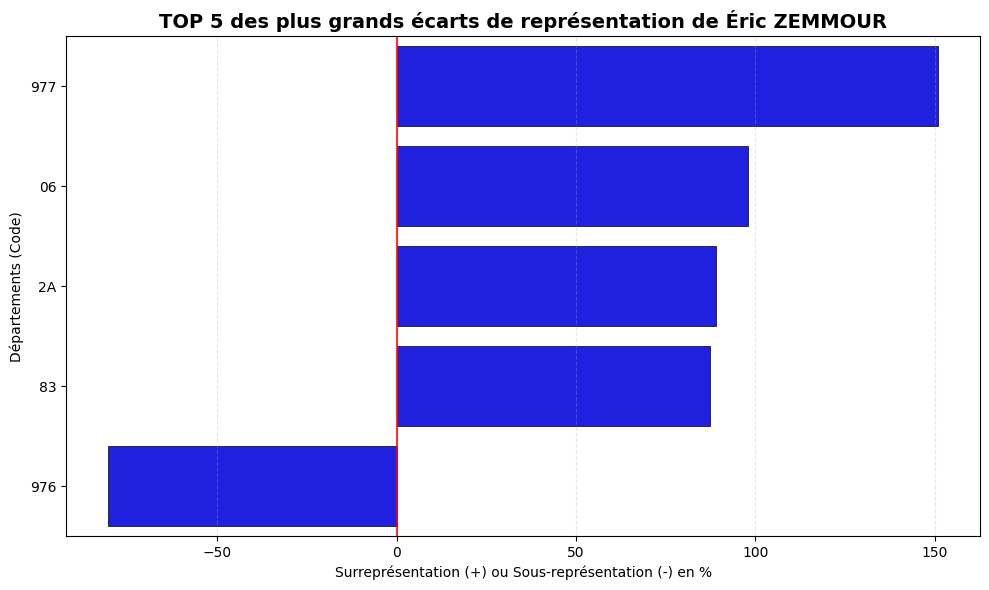

In [24]:
## affichage pour Eric Zemmour
plot_top_surrepresentations(data=score_departements, candidat='Éric ZEMMOUR', nb_dep=5)

## affichage pour Emmannuel Macron
##plot_top_surrepresentations(data=score_departements, candidat='Emmanuel MACRON', nb_dep=5)

# 3. Un peu de cartographie

## Données

Nous importons ici les données geojson contenant le fond de carte  des départements de France.

In [ ]:
departement_borders = carti_download(
    values=["France"],
    crs=4326,
    borders="DEPARTEMENT",
    vectorfile_format="geojson",
    simplification=50,
    filter_by="FRANCE_ENTIERE_DROM_RAPPROCHES",
    source="EXPRESS-COG-CARTO-TERRITOIRE",
    year=2022
)

departement_borders.head()

In [ ]:
score_departements = votes_departementaux.copy()

score_departements.head()

## Carte pour Marine LE PEN

Dans cette partie, nous avons construit une visualisation cartographique des scores électoraux par département en structurant le code en plusieurs fonctions qui se trouvent dans le fichier **utils.py**.

Tout d’abord, la fonction `filtrer_candidat` permet de restreindre la base `score_departements` à un candidat donné, sans modifier les données initiales. Les données ainsi filtrées sont ensuite fusionnées avec le fond de carte des départements via la fonction `merge_carte`, afin d’associer à chaque département son score électoral.

La représentation cartographique est ensuite réalisée grâce à la fonction `plot_carte`, qui génère une carte choroplèthe en paramétrant notamment les couleurs, la légende et les contours des départements pour améliorer la lisibilité. Enfin, les fonctions `carte_par_candidat` et `cartes_plusieurs_candidats` permettent respectivement d’afficher la carte pour un candidat donné ou d’automatiser la génération pour plusieurs candidats.


La carte des scores de Marine LE PEN met en évidence une forte structuration territoriale de son électorat. On observe des scores particulièrement élevés dans le nord et le nord-est de la France, ainsi que dans certains départements du sud, traduisant un ancrage important dans ces zones.

À l’inverse, les scores apparaissent plus faibles dans l’ouest du pays, ce qui suggère une moindre implantation dans ces régions. Ces contrastes illustrent des disparités géographiques marquées, pouvant être liées à des facteurs socio-économiques ou encore la structure démographique.

La carte permet ainsi de visualiser clairement les zones de force et de faiblesse du candidat, offrant une lecture synthétique et immédiate des dynamiques électorales sur le territoire.

In [ ]:
## Carte pour Marine LE PEN
carte_par_candidat(score_departements, departement_borders, "Marine LE PEN",epais_lim=1.4,long_legend= 10)

Nous présentons ci-dessous les cartes de tous les candidats en utilisant la fonction `cartes_plusieurs_candidats` présenté ci-haut.

In [ ]:
liste_candidats = score_departements["Candidat"].unique().tolist()

cartes_plusieurs_candidats(
    df=score_departements,
    df_geo=departement_borders,
    liste_candidats=liste_candidats,
    indicateur="Score (% votes exprimés)",
    epais_lim=1.4,
    long_legend= 10
)
